In [ ]:
!pip install utilsforecast statsforecast fpppy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 34.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found exi

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Cargar Librerias para tratamiento de datos
import missingno as mno
import random
import os
from math import sqrt
from datetime import datetime
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsmodels.tsa.arima.model import ARIMA
from statsforecast.arima import ARIMASummary
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from xgboost import XGBRegressor
import statsmodels.api as sm
import os

In [ ]:
# ================== 1. cargar datos ==================
#station_id = "84501"
#csv_path = f"data/station{station_id}.csv"
station_id = os.environ["STATION_ID"]
csv_path = f"data/station{station_id}.csv"

df = pd.read_csv(csv_path, parse_dates=["time"])
df = df.set_index("time").sort_index()

df = df.drop(columns=["NINO12","NINO34"])
df["log_prcp"] = np.log1p(df["prcp"])

Feature Engineering

In [ ]:
# ================== 2. Lags (OK antes del split) ==================
for k in [1,3,6,12]:
    df[f"prcp_lag{k}"] = df["log_prcp"].shift(k)

for k in range(1,13):
    df[f"ANOM34_lag{k}"] = df["NINO34ANOM"].shift(k)

for k in [1,3]:
    df[f"ICEN_lag{k}"] = df["ICEN"].shift(k)

# ================== 3. Dummies de mes ================== X month_sin y month_cos
df["month"] = df.index.month
#df = pd.get_dummies(df, columns=["month"], prefix="month", drop_first=False)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

#for m in range(1, 13):
#    col = f"month_{m}"
#    if col not in df.columns:
#        df[col] = 0

In [ ]:
# ================== 4. Split base ==================
split_idx = int(len(df) * 0.8)
df_train = df.iloc[:split_idx].copy()   # 1982-2017 (428)
df_test  = df.iloc[split_idx:].copy()   # 2017-2026 (107)

def add_rollings_precenso(d):
    d["prcp_roll3"]  = d["log_prcp"].rolling(3).mean()
    d["prcp_roll6"]  = d["log_prcp"].rolling(6).mean()
    d["prcp_roll12"] = d["log_prcp"].rolling(12).mean()
    d["prcp_std6"]   = d["log_prcp"].rolling(6).std()
    d["enso34_roll3"]  = d["NINO34ANOM"].rolling(3).mean()
    d["ICEN_roll3"] = d["ICEN"].rolling(3).mean()

add_rollings_precenso(df_train)
add_rollings_precenso(df_test)

# ================== 6. Concatenar ==================
df_model = pd.concat([df_train, df_test])

In [ ]:
# ================== 7. Definir grupos de columnas ==================
lag_features = (
    [f"prcp_lag{k}" for k in [1,3,6,12]] +
    # [f"ANOM12_lag{k}" for k in range(1,13)] +
    [f"ANOM34_lag{k}" for k in range(1,13)] +
    [f"ICEN_lag{k}" for k in [1,3]]
)

rolling_features = [
    "prcp_roll3", "prcp_roll6", "prcp_roll12","prcp_std6",
    "enso34_roll3", #"enso34_roll6",
    "ICEN_roll3"#,"ICEN_roll6"
]

# month_features = [col for col in df.columns if col.startswith("month_")]
month_features = ["month_sin", "month_cos"]

feature_cols = lag_features + rolling_features + month_features

exog_sarimax = ["NINO34ANOM","ICEN_lag1"]

In [ ]:
# ================== 8. Armar df_model limpio (XGB) ==================
df_model = df_model[["log_prcp", "ICEN","NINO34ANOM"] + feature_cols].dropna()

# agregar nuevo split_idx basado en df_model ya sin NaN
split_idx = int(len(df_model) * 0.8)

y = df_model["log_prcp"]
X_xgb      = df_model[feature_cols]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

true_train = np.expm1(y_train)
true_test  = np.expm1(y_test)

X_train = X_xgb.iloc[:split_idx]
X_test = X_xgb.iloc[split_idx:]

In [ ]:
# ================== 9. Exógenas para SARIMAX ==================
exog_train = df_model[exog_sarimax].iloc[:split_idx]   # sarimax 1 var. exógena
exog_test  = df_model[exog_sarimax].iloc[split_idx:]

# ---------------------------------
# ----- Funciones auxiliares ------
# ---------------------------------
def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

In [ ]:
df_model.columns

Index(['log_prcp', 'ICEN', 'NINO34ANOM', 'prcp_lag1', 'prcp_lag3', 'prcp_lag6',
       'prcp_lag12', 'ANOM34_lag1', 'ANOM34_lag2', 'ANOM34_lag3',
       'ANOM34_lag4', 'ANOM34_lag5', 'ANOM34_lag6', 'ANOM34_lag7',
       'ANOM34_lag8', 'ANOM34_lag9', 'ANOM34_lag10', 'ANOM34_lag11',
       'ANOM34_lag12', 'ICEN_lag1', 'ICEN_lag3', 'prcp_roll3', 'prcp_roll6',
       'prcp_roll12', 'prcp_std6', 'enso34_roll3', 'ICEN_roll3', 'month_sin',
       'month_cos'],
      dtype='object')

In [ ]:
corr_matrix = df_model[['ICEN', 'NINO34ANOM',
                        'prcp_lag1', 'prcp_lag3','prcp_lag6', 'prcp_lag12',
                        'ANOM34_lag1', 'ANOM34_lag6', 'enso34_roll3',
                        'ICEN_lag1', 'ICEN_roll3',
                        'prcp_roll3', 'prcp_roll6', 'prcp_std6',
                        'month_sin', 'month_cos']].corr()

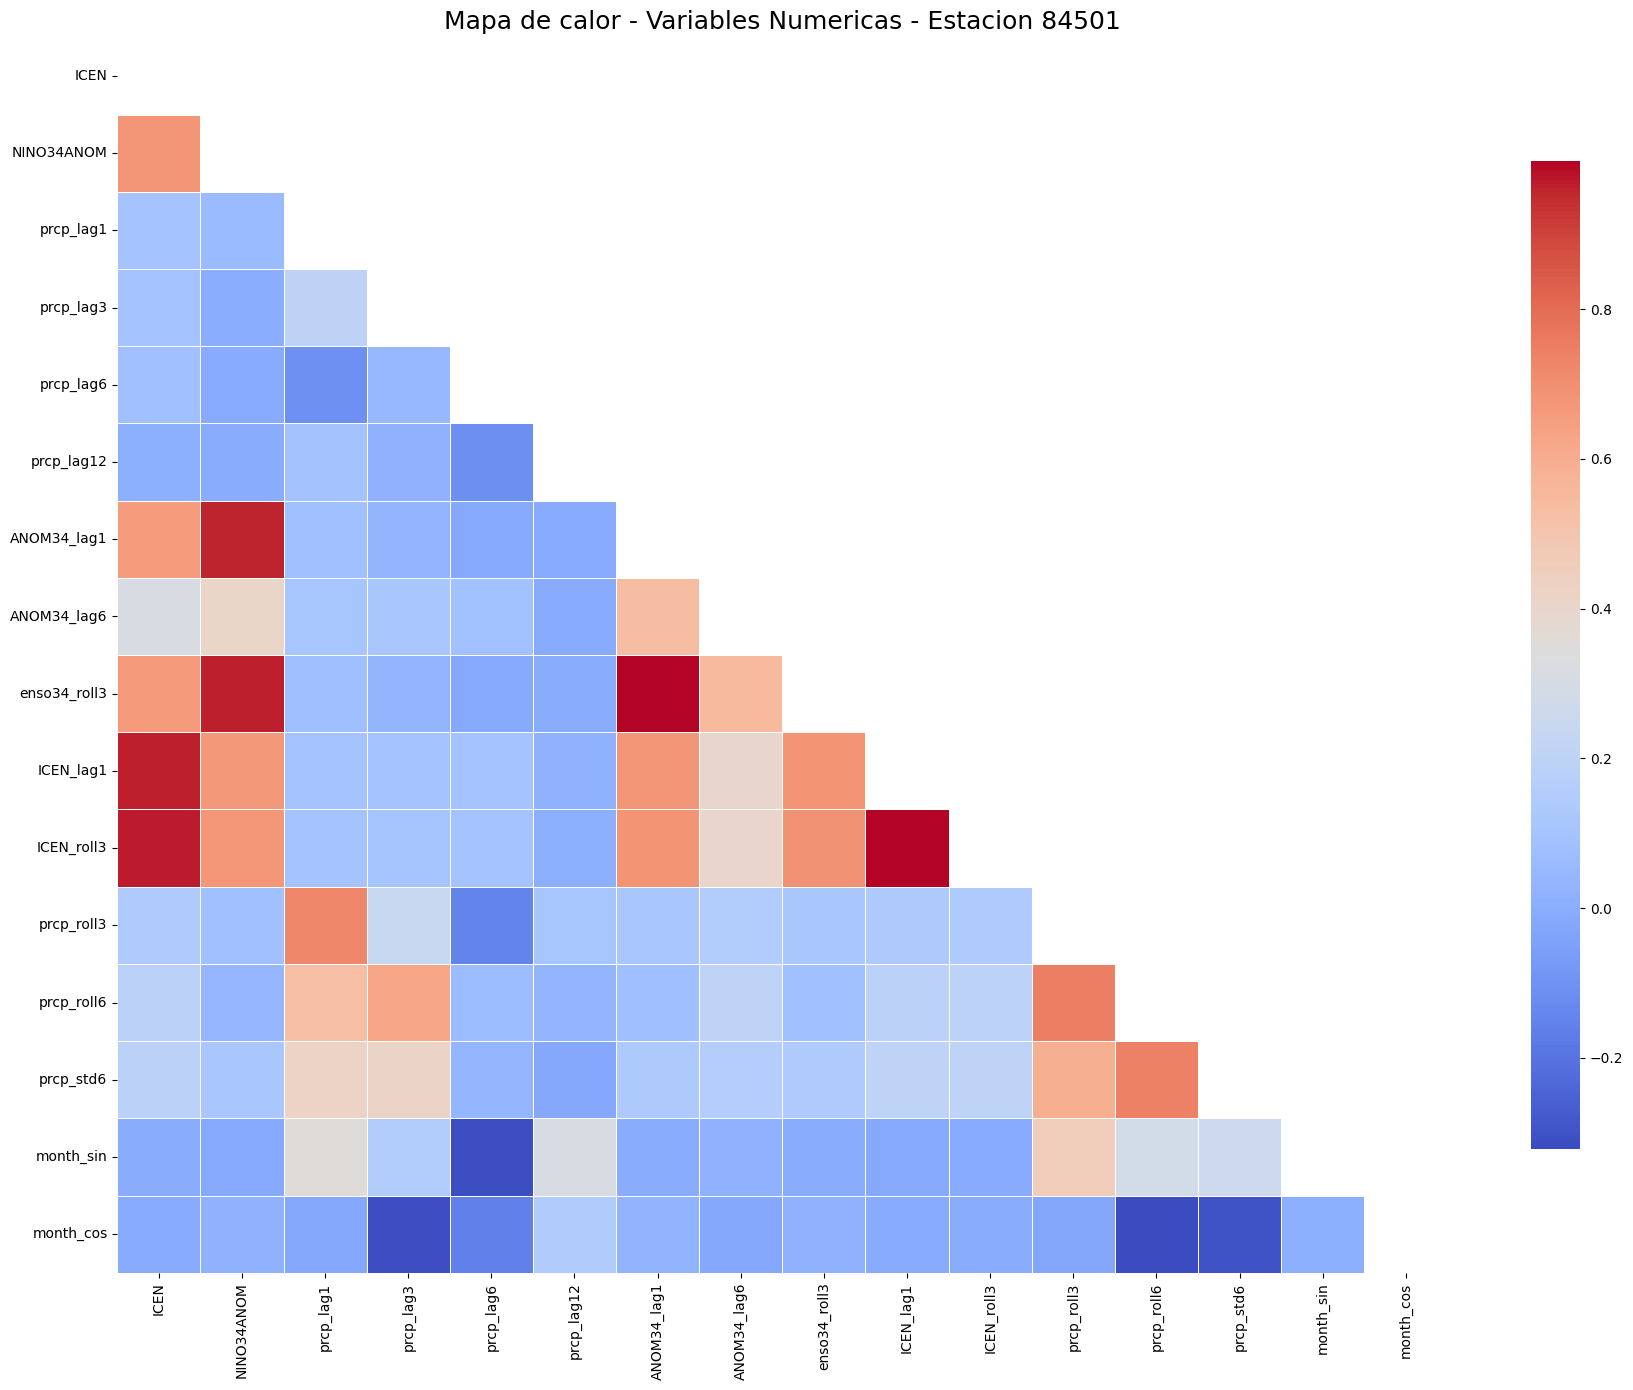

In [ ]:
plt.figure(figsize=(18, 14))

# Máscara para ocultar la mitad superior (opcional pero recomendado)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    annot=False,        # True si quieres números dentro
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Mapa de calor - Variables Numericas - Estacion 84501", fontsize=18)
plt.tight_layout()
plt.show()


In [ ]:
columnas_pa_xgb = ['NINO34ANOM','ICEN','ICEN_lag1','ICEN_roll3',
                     'prcp_lag1','prcp_lag3','prcp_lag6','prcp_lag12',
                     'prcp_roll3', 'prcp_roll6',
                     'ANOM34_lag1', 'ANOM34_lag6','enso34_roll3',
                     'month_sin', 'month_cos']

In [ ]:
# array de resultados
resultados = []

####### MODELO GANADOR #######
exog_sarimax = ['NINO34ANOM',"ICEN_lag1"]
df_sarimax = df_model[["log_prcp"] + exog_sarimax].dropna()

split_idx_sarimax = int(len(df_sarimax) * 0.8)

y_sarimax = df_sarimax["log_prcp"]
exog_sarimax_full = df_sarimax[exog_sarimax]

y_train_sarimax = y_sarimax.iloc[:split_idx_sarimax]
y_test_sarimax  = y_sarimax.iloc[split_idx_sarimax:]

exog_train_sarimax = exog_sarimax_full.iloc[:split_idx_sarimax]
exog_test_sarimax  = exog_sarimax_full.iloc[split_idx_sarimax:]

sarimax_model = sm.tsa.statespace.SARIMAX(
    y_train_sarimax,
    exog=exog_train_sarimax,
    order=(2,0,2),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
sarimax_train_pred = sarimax_model.predict(start=y_train.index[0], end=y_train.index[-1], exog=exog_train_sarimax)

start = len(y_train)
end = len(y_train) + len(y_test) - 1

sarimax_test_pred = sarimax_model.predict(start=start, end=end, exog=exog_test_sarimax)
sarimax_test_pred_series = pd.Series(sarimax_test_pred.values, index=y_test.index)

residuals_train = y_train - sarimax_train_pred

In [ ]:
sarimax_train_real = np.expm1(sarimax_train_pred)
sarimax_test_real  = np.expm1(sarimax_test_pred)

true_train_sarimax = np.expm1(y_train_sarimax)
true_train_sarimax_series = pd.Series(true_train_sarimax.values, index=y_train.index)
true_test_sarimax  = np.expm1(y_test_sarimax)
true_test_sarimax_series = pd.Series(true_test_sarimax.values, index=y_test.index)

rmse_sarimax = rmse(true_test_sarimax, sarimax_test_real)
mae_sarimax  = mae(true_test_sarimax, sarimax_test_real)

resultados.append({
    "modelo": "SARIMAX (2,0,2) (1,1,1,12) ENSO rezagado",
    "RMSE": rmse_sarimax,
    "MAE": mae_sarimax
})

In [ ]:
resultados

[{'modelo': 'SARIMAX (2,0,2) (1,1,1,12) ENSO rezagado',
  'RMSE': 2.9987222550466717,
  'MAE': 1.5707648153634344}]

In [ ]:
# Confirmación de que los valores están en mm (no en log)
#print(true_test_sarimax.describe())
#print(sarimax_test_real.describe())

In [ ]:
# ================== 8. volver a armar df_model para XGB ==================
df_model["prcp"] = np.expm1(df_model["log_prcp"])
df_model = df_model[["prcp"] + columnas_pa_xgb].dropna()

In [ ]:
# re-agregar nuevo split_idx basado en df_model ya sin NaN
split_idx = int(len(df_model) * 0.8)

#y     = df_model["log_prcp"]
y     = df_model["prcp"]
X_xgb = df_model[columnas_pa_xgb]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

true_train = np.expm1(y_train)
true_test  = np.expm1(y_test)

X_train = X_xgb.iloc[:split_idx].drop(columns='ICEN')
X_test = X_xgb.iloc[split_idx:].drop(columns='ICEN')

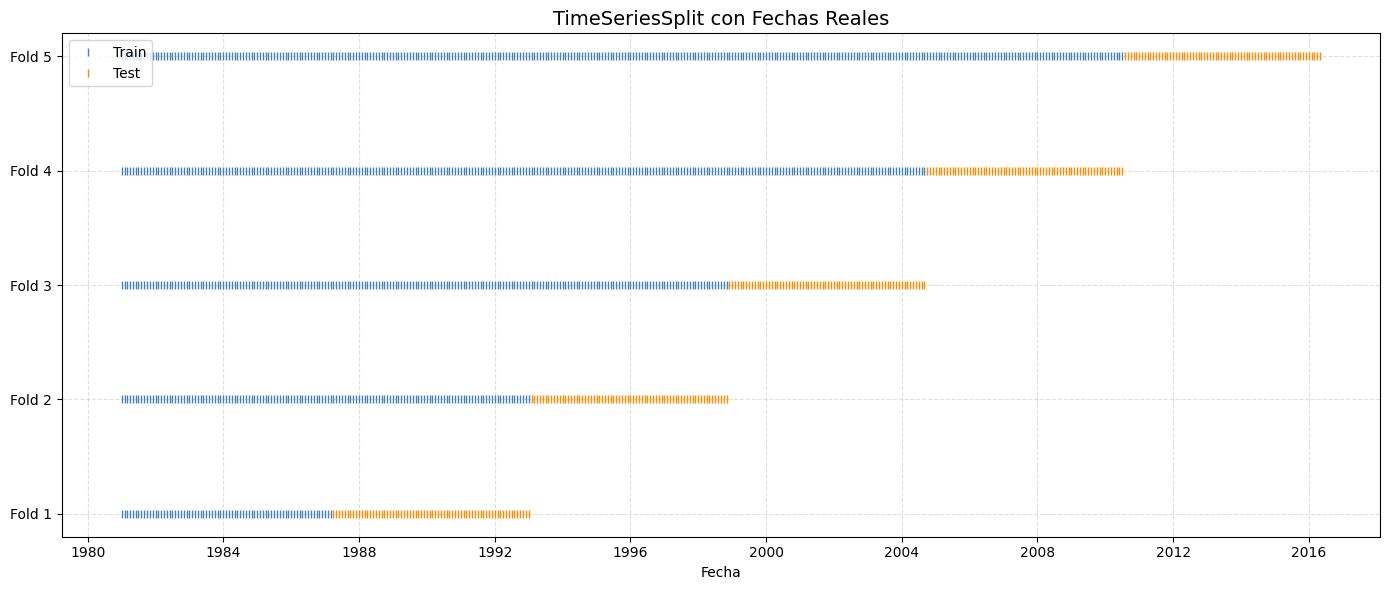

Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [ ]:
# XGBOOST
randomstate = 42
tscv = TimeSeriesSplit(n_splits=5)

####
# Asegurar que el índice de X_train sea datetime
dates = X_train.index

plt.figure(figsize=(14, 6))

fold = 1
for train_idx, test_idx in tscv.split(X_train):

    # Fechas reales
    train_dates = dates[train_idx]
    test_dates = dates[test_idx]

    # Train
    plt.plot(train_dates,
             [fold]*len(train_dates),
             marker='|',
             linestyle='None',
             color='steelblue',
             label='Train' if fold == 1 else "")

    # Test
    plt.plot(test_dates,
             [fold]*len(test_dates),
             marker='|',
             linestyle='None',
             color='darkorange',
             label='Test' if fold == 1 else "")

    fold += 1

plt.yticks(range(1, 6), [f"Fold {i}" for i in range(1, 6)])
plt.title("TimeSeriesSplit con Fechas Reales", fontsize=14)
plt.xlabel("Fecha")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

####

param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 1, 5],
    "min_child_weight": [1, 3, 5],
}

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric= "mae",
    random_state=randomstate)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=40,
    scoring="neg_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train.to_numpy(), y_train.to_numpy())
best_xgb = search.best_estimator_

In [ ]:
# sarimax_train_real & sarimax_test_real
xgb_train_pred = best_xgb.predict(X_train)
xgb_train_pred_series = pd.Series(xgb_train_pred, index=X_train.index) #xgb_train_pred_series
xgb_test_pred  = best_xgb.predict(X_test)
xgb_test_pred_series = pd.Series(xgb_test_pred, index=X_test.index) #xgb_test_pred_series

hybrid2_train = true_train_sarimax_series + xgb_train_pred_series

# modelo hibrido basico (pesos con promedio fijo)
hybrid2_test  = 0.5 * true_test_sarimax_series  + 0.5 * xgb_test_pred_series

# Peso dinámico para extremos
peso_xgb = np.clip(xgb_test_pred_series / (xgb_test_pred_series.max() + 1e-6), 0, 1)

# Híbrido mejorado
hybrid_ext = (1 - peso_xgb) * true_test_sarimax_series + peso_xgb * xgb_test_pred_series

In [ ]:
# comparar historico vs modelo hibrido mejorado

df_compare = pd.DataFrame({
    "historic": df_model["prcp"],
    "hybrid_ext": hybrid_ext
})
print(df_compare.tail(12))

            historic  hybrid_ext
time                            
2025-04-01       1.0    1.006565
2025-05-01       0.5    0.690712
2025-06-01       0.5    0.498635
2025-07-01       0.5    0.521573
2025-08-01       0.0    0.005280
2025-09-01       0.0    0.001394
2025-10-01       0.5    0.495819
2025-11-01       0.5    0.501222
2025-12-01       0.0    0.024576
2026-01-01      10.0    8.155227
2026-02-01       3.0    2.871785
2026-03-01       0.5    1.045275


Prediccion futura

In [ ]:
# ================== 8. volver a armar df_model para XGB ==================
df_model["log_prcp"] = np.log1p(df_model["prcp"])
df_model = df_model[["log_prcp"] + columnas_pa_xgb].dropna()

In [ ]:
# ================================
# 1. Crear df_future base
# ================================
H = 12

future_index = pd.date_range(
    start=df_model.index[-1] + pd.offsets.MonthBegin(1),
    periods=H,
    freq="MS"
)

df_future = pd.DataFrame(index=future_index)

# ENSO futuro
df_future["NINO34ANOM"] = [0.10, 0.23, 1.4, 1.7, 1.9, 1.8, 1.6, 1.3, 1.0, 0.8, 0.6, 0.4]
df_future["ICEN_lag1"] = df_model["ICEN"].shift(1).iloc[-12:].values

# ================================
# 2. Extender df original
# ================================
df_ext = pd.concat([df_model[["log_prcp","ICEN"]], df_future], axis=0)

# ================================
# 3. Month dummies X   month_sin y month_cos
# ================================
# ================== 3. Dummies de mes ==================
df_ext["month"] = df_ext.index.month
df_ext["month_sin"] = np.sin(2 * np.pi * df_ext["month"] / 12)
df_ext["month_cos"] = np.cos(2 * np.pi * df_ext["month"] / 12)

In [ ]:
# ================================
# 4. Regenerar TODAS las features en df_ext
# ================================

# Lags prcp
for k in [1,3,6,12]:
    df_ext[f"prcp_lag{k}"] = df_ext["log_prcp"].shift(k)

# Lags ENSO
for k in [1,6]:
    df_ext[f"ANOM34_lag{k}"] = df_ext["NINO34ANOM"].shift(k)

for k in [1]:
    df_ext[f"ICEN_lag{k}"] = df_ext["ICEN"].shift(k)

In [ ]:
# Rolling prcp
df_ext["prcp_roll3"]  = df_ext["log_prcp"].rolling(3).mean()
df_ext["prcp_roll6"]  = df_ext["log_prcp"].rolling(6).mean()

# Rolling ENSO
df_ext["enso34_roll3"] = df_ext["NINO34ANOM"].rolling(3).mean()
df_ext["ICEN_roll3"] = df_ext["ICEN"].rolling(3).mean()

In [ ]:
# ================================
# 5. Seleccionar exógenas SARIMAX
# ================================

exog_sarimax = ["ICEN_lag1","NINO34ANOM"]
exog_future = df_ext.loc[future_index, exog_sarimax].fillna(0)

# ================================
# 6. Seleccionar features XGB
# ================================
X_future = df_ext.loc[future_index, X_train.columns].fillna(0)

In [ ]:
# ================================
# 7. Forecast SARIMAX
# ================================
start = sarimax_model.nobs
end   = sarimax_model.nobs + H - 1

sarimax2_forecast = sarimax_model.predict(start=start, end=end, exog=exog_future)
sarimax2_forecast = np.array(sarimax2_forecast)
sarimax2_future_series = pd.Series(sarimax2_forecast, index=future_index, name="sarimax forecast")

In [ ]:
# ================================
# 8. Forecast XGB futuro
# ================================
xgb_future_pred = best_xgb.predict(X_future.to_numpy())
xgb_future_series = pd.Series(xgb_future_pred, index=future_index, name="xgb forecast")

# ================================
# 9. Modelo híbrido (mejorado)
# ================================
peso_xgb_future = np.clip(xgb_future_series / (xgb_future_series.max() + 1e-6), 0, 1)

hybrid_ext_future = ((1 - peso_xgb_future) * sarimax2_future_series) + (peso_xgb_future * xgb_future_series)

Escenarios

In [ ]:
# ================================
# 8. Escenarios ENSO 3.4
# ================================

scenarios = {
    "nino_fuerte":  [1.2, 1.4, 1.6, 1.8, 2.0, 2.1, 2.0, 1.8, 1.5, 1.2, 1.0, 0.8],
    "nino_fuerte_2": [0.3, 0.5, 0.7, 0.9, 1.2, 1.6, 2.0, 2.3, 2.4, 2.1, 1.7, 1.3],
    "nino_fuerte_3": [0.2, 0.3, 0.5, 0.8, 1.1, 1.4, 1.7, 1.9, 2.0, 1.8, 1.4, 1.0],
    "nino_moderado": [0.8, 1.0, 1.1, 1.2, 1.3, 1.2, 1.1, 1.0, 0.8, 0.6, 0.4, 0.3],
    "neutral":      [0.1, 0.0, -0.1, 0.0, 0.1, 0.0, -0.1, 0.0, 0.1, 0.0, -0.1, 0.0],
    "nina_moderada":[-0.5, -0.7, -0.9, -1.0, -1.1, -1.0, -0.8, -0.6, -0.4, -0.3, -0.2, -0.1]
}

for scen_name, scen_values in scenarios.items():

    df_future_scen = df_future.copy()
    df_future_scen["NINO34ANOM"] = scen_values

    # Concatenar df histórico + df_future_scen
    df_ext = pd.concat([df, df_future_scen], axis=0)

    # Rellenar ICEN futuro con forward-fill
    df_ext["ICEN"] = df_ext["ICEN"].ffill()
    # Reconstruir ICEN_lag1 correctamente
    df_ext["ICEN_lag1"] = df_ext["ICEN"].shift(1)
    df_future_scen["ICEN_lag1"] = df_ext["ICEN_lag1"].loc[future_index]

    # ============================================
    # Reconstrucción de las demás features
    # ============================================

    # -------------------------
    # Lags de precipitación
    # -------------------------
    for k in [1, 3, 6, 12]:
        df_ext[f"prcp_lag{k}"] = df_ext["prcp"].shift(k)

    # -------------------------
    # Rollings de precipitación
    # -------------------------
    df_ext["prcp_roll3"] = df_ext["prcp"].rolling(3).mean()
    df_ext["prcp_roll6"] = df_ext["prcp"].rolling(6).mean()

    # -------------------------
    # ENSO rezagos
    # -------------------------
    df_ext["ANOM34_lag1"] = df_ext["NINO34ANOM"].shift(1)
    df_ext["ANOM34_lag6"] = df_ext["NINO34ANOM"].shift(6)

    # -------------------------
    # ENSO rolling
    # -------------------------
    df_ext["enso34_roll3"] = df_ext["NINO34ANOM"].rolling(3).mean()

    # ICEN ROLL
    df_ext["ICEN_roll3"] = df_ext["ICEN"].rolling(3).mean()

    # -------------------------
    # Estacionalidad
    # -------------------------
    df_ext["month"] = df_ext.index.month
    df_ext["month_sin"] = np.sin(2 * np.pi * df_ext["month"] / 12)
    df_ext["month_cos"] = np.cos(2 * np.pi * df_ext["month"] / 12)

    df_ext = df_ext[X_train.columns]

    X_future_scen = df_ext.loc[future_index, X_train.columns].fillna(0)

    # SARIMAX (log -> real)
    sarimax_log_scen = sarimax_model.get_forecast(
        steps=12,
        exog=df_future_scen[["NINO34ANOM", "ICEN_lag1"]]
    ).predicted_mean.values

    # Convertir SARIMAX a precipitación real
    sarimax_real_scen = np.expm1(sarimax_log_scen)

    # XGB (real)
    xgb_real_scen = best_xgb.predict(X_future_scen.to_numpy())

    # ============================
    # Híbrido mejorado para extremos
    # ============================
    # crear peso dinámico: XGB domina cuando predice valores altos
    peso_xgb_scen = np.clip(xgb_real_scen / (xgb_real_scen.max() + 1e-6), 0, 1)

    # Hybrid
    hybrid_ext_scen = ((1 - peso_xgb_scen) * sarimax_real_scen + (peso_xgb_scen * xgb_real_scen))

    # Guardar CSV
    scen_df = pd.DataFrame({
        "time": future_index,
        "sarimax": sarimax_real_scen,
        "xgb": xgb_real_scen,
        "hybrid": hybrid_ext_scen
    })

    scen_df.to_csv(f"data/pred_{station_id}_{scen_name}.csv", index=False)

In [ ]:
# para grafico streamlit
dhistoric = y.to_frame("historic").reset_index().rename(columns={"index": "time"})
dsarimax = sarimax2_future_series.to_frame("sarimax").reset_index().rename(columns={"index": "time"})
dxgb = xgb_future_series.to_frame("xgb").reset_index().rename(columns={"index": "time"})
dhybrid = hybrid_ext_future.to_frame("hybrid").reset_index().rename(columns={"index": "time"})

df_final = (
    dhistoric
    .merge(dsarimax, on="time", how="outer")
    .merge(dxgb, on="time", how="outer")
    .merge(dhybrid, on="time", how="outer")
    .sort_values("time")
)

csvfilefinal = "data/pred_" + station_id + ".csv"
df_final.to_csv(csvfilefinal, index=False)

In [ ]:
# test sets
test_df = pd.DataFrame({
    "time": true_test_sarimax.index,
    "real": true_test_sarimax.values,
    "sarimax": sarimax_test_pred_series.values,
    "xgb": xgb_test_pred_series.values,
    "hybrid": hybrid_ext.values
})

test_df.set_index("time", inplace=True)

csvfiletest = "data/testsets_" + station_id + ".csv"
test_df.to_csv(csvfiletest)